In [13]:
from sentence_transformers import SentenceTransformer

# Load the model
import tqdm as notebook_tqdm
model = SentenceTransformer("Qwen/Qwen3-Embedding-0.6B")

Loading weights: 100%|██████████| 310/310 [00:00<00:00, 10571.87it/s]


In [14]:
# Import required libraries for image downloading and display
import requests
from requests.auth import HTTPBasicAuth
from io import BytesIO
from PIL import Image as PILImage
from IPython.display import display
import os
from dotenv import load_dotenv
load_dotenv()

# Nextcloud configuration - get from environment variables
NC_HOST = os.getenv("DB_HOST")
NC_ACC = os.getenv("NC_ACC")
NC_PASS = os.getenv("NC_PASS")

print(f"Nextcloud host: {NC_HOST}")
print(f"Nextcloud account: {NC_ACC}")

Nextcloud host: 192.168.0.150
Nextcloud account: Tom


In [15]:
def get_images(file_id, file_path):
    """
    Download and display a thumbnail/preview for a file from Nextcloud.
    
    Args:
        file_id: The Nextcloud file ID
        file_path: The path to the file on the Nextcloud server
    
    Returns:
        PIL.Image: The resized 256x256 PIL Image
    """
    server_url = f'http://{NC_HOST}:8080/remote.php/dav/files/{NC_ACC}'
    preview_url = f'http://{NC_HOST}:8080/core/preview?fileId={file_id}&x=1080&y=1080'
    username = NC_ACC
    password = NC_PASS

    # Construct the full URL
    file_url = f"{server_url}{file_path}"

    # Send a GET request to download the file
    response = requests.get(preview_url, auth=HTTPBasicAuth(username, password), stream=True)
 
    # Check if the request was successful
    if response.status_code == 200:
        # Save the file content in memory using BytesIO
        file_in_memory = BytesIO()
        for chunk in response.iter_content(chunk_size=1024):
            if chunk:
                file_in_memory.write(chunk)
        file_in_memory.seek(0)  # Move the pointer to the start of the BytesIO object
        size_in_bytes = len(file_in_memory.getvalue())
        size_in_mb = size_in_bytes / (1024 * 1024)  # Convert bytes to megabytes
        #print(f"Image size: {size_in_mb:.2f} MB")

        # Open the image using Pillow (PIL)
        img = PILImage.open(file_in_memory)
        w, h = img.size
        #print('width:', w, 'height:', h)
        img = img.resize((256, 256))
        display(img)
    elif response.status_code == 404:
        #print("No preview available for this file.")
        try:
            response = requests.get(file_url, auth=HTTPBasicAuth(username, password), stream=True)
            file_in_memory = BytesIO()
            for chunk in response.iter_content(chunk_size=1024):
                if chunk:
                    file_in_memory.write(chunk)
            file_in_memory.seek(0)  # Move the pointer to the start of the BytesIO object
            size_in_bytes = len(file_in_memory.getvalue())
            size_in_mb = size_in_bytes / (1024 * 1024)  # Convert bytes to megabytes
            #print(f"File size: {size_in_mb:.2f} MB")
            source_img = PILImage.open(file_in_memory)
            img = source_img.resize((1080, 1080))
            img_display = source_img.resize((256, 256))
            display(img_display)
        except Exception as e:
            print(f"Failed to download file. Exception: {e}")
    else:
        print(f"Failed to download file. Status code: {response.status_code}")
        print(response.text)
    try:
        import gc
        del file_in_memory
        gc.collect()
    except:
        pass
    return img

In [16]:
from dotenv import load_dotenv
import os
from sqlalchemy import create_engine, MetaData, Table, select, insert
from sqlalchemy.exc import SQLAlchemyError
load_dotenv()
import pandas as pd



def create_db_connection():
    load_dotenv()
    
    DB_HOST = os.getenv("DB_HOST")
    DB_NAME = os.getenv("DB_NAME")
    DB_USER = os.getenv("DB_USER")
    DB_PASSWORD = os.getenv("DB_PASSWORD")
    engine = create_engine('postgresql+pg8000://'+DB_USER+':'+DB_PASSWORD+'@'+DB_HOST+':5432/'+DB_NAME)
    return engine


In [17]:
def get_tags():
    try:
        engine = create_db_connection()
        df_systag = pd.read_sql_table('oc_systemtag', engine)
        df_tagmap = pd.read_sql_table('oc_systemtag_object_mapping', engine)

    except SQLAlchemyError as e:
        print(f"An error occurred: {e}")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
    return df_systag, df_tagmap

In [18]:
engine = create_db_connection()

In [19]:
df_systag, df_tagmap = get_tags()

In [20]:
df_systag

,id,name,visibility,editable,etag,color
0,819,flower,1,1,None,None
1,820,nature,1,1,None,None
2,821,still,1,1,None,None
3,822,life,1,1,None,None
4,823,vase,1,1,None,None
...,...,...,...,...,...,...
761,1581,tender,1,1,None,None
762,1582,emotive,1,1,None,None
763,1583,room,1,1,None,None
764,1584,bed,1,1,None,None


In [21]:

def search_tags_with_nlp(query, top_k=10):
    # Step 1: Embed the user query using the query prompt
    query_embedding = model.encode(query, prompt_name="query")
    
    # Step 2: Embed all tags for comparison
    all_tags = df_systag['name'].tolist()
    tag_embeddings = model.encode(all_tags)
    
    # Step 3: Compute cosine similarity between query and all tags
    similarity = model.similarity(torch.tensor(query_embedding).unsqueeze(0), torch.tensor(tag_embeddings))
    
    # Step 4: Get top-k most similar tags
    top_indices = similarity[0].argsort(descending=True)[:top_k]
    
    # Step 5: Build results DataFrame
    results = pd.DataFrame({
        'tag_id': df_systag.iloc[top_indices]['id'].values,
        'tag_name': df_systag.iloc[top_indices]['name'].values,
        'similarity': similarity[0][top_indices].cpu().numpy()
    })
    
    # Step 6: Map tag IDs to file IDs via oc_systemtag_object_mapping
    results_with_files = results.merge(
        df_tagmap[df_tagmap['systemtagid'].isin(results['tag_id'])][['systemtagid', 'objectid']],
        left_on='tag_id',
        right_on='systemtagid',
        how='left'
    )
    
    # Group file IDs by tag (as a list)
    results_with_files = results_with_files.groupby(['tag_id', 'tag_name', 'similarity'])['objectid'].apply(list).reset_index()
    results_with_files = results_with_files.rename(columns={'objectid': 'file_ids'})
    
    return results_with_files


def get_all_file_ids_from_query(query, top_k=10):
    """
    Returns a unique list of all file IDs matching the query tags.
    """
    results = search_tags_with_nlp(query, top_k=top_k)
    
    # Collect all unique file IDs
    all_file_ids = set()
    for file_ids in results['file_ids']:
        if file_ids:
            all_file_ids.update(file_ids)
    
    return sorted(list(all_file_ids)), results

def get_images(file_id,file_path):
    load_dotenv()
    
    DB_HOST = os.getenv("DB_HOST")
    DB_NAME = os.getenv("DB_NAME")
    DB_USER = os.getenv("DB_USER")
    NC_ACC = os.getenv("NC_ACC")
    NC_PASS = os.getenv('NC_PASS')
    server_url = f'''http://{DB_HOST}:8080/remote.php/dav/files/{NC_ACC}'''
    preview_url = f'''http://{DB_HOST}:8080/core/preview?fileId={file_id}&x=1080&y=1080'''
    username = NC_ACC
    password = NC_PASS

    # Construct the full URL
    file_url = f"{server_url}{file_path}"

    # Send a GET request to download the file
    response = requests.get(preview_url, auth=HTTPBasicAuth(username, password), stream=True)
 
    # Check if the request was successful
    if response.status_code == 200:
        # Save the file content in memory using BytesIO
        file_in_memory = BytesIO()
        for chunk in response.iter_content(chunk_size=1024):
            if chunk:
                file_in_memory.write(chunk)
        file_in_memory.seek(0)  # Move the pointer to the start of the BytesIO object
        size_in_bytes = len(file_in_memory.getvalue())
        size_in_mb = size_in_bytes / (1024 * 1024)  # Convert bytes to megabytes
        #print(f"Image size: {size_in_mb:.2f} MB")

        # Open the image using Pillow (PIL)
        img = PILImage.open(file_in_memory)
        w, h = img.size
        #print('width:', w, 'height:', h)
        img = img.resize((256, 256))
        display(img)
    elif response.status_code == 404:
        #print("No preview available for this file.")
        try:
            response = requests.get(file_url, auth=HTTPBasicAuth(username, password), stream=True)
            file_in_memory = BytesIO()
            for chunk in response.iter_content(chunk_size=1024):
                if chunk:
                    file_in_memory.write(chunk)
            file_in_memory.seek(0)  # Move the pointer to the start of the BytesIO object
            size_in_bytes = len(file_in_memory.getvalue())
            size_in_mb = size_in_bytes / (1024 * 1024)  # Convert bytes to megabytes
            #print(f"File size: {size_in_mb:.2f} MB")
            source_img = PILImage.open(file_in_memory)
            img = source_img.resize((1080, 1080))
            img_display = source_img.resize((256, 256))
            display(img_display)
        except Exception as e:
            print(f"Failed to download file. Exception: {e}")
    else:
        print(f"Failed to download file. Status code: {response.status_code}")
        print(response.text)
    try:
        import gc
        del file_in_memory
        gc.collect()
    except:
        pass
    return img


Loading model...


Loading weights: 100%|██████████| 310/310 [00:00<00:00, 9637.43it/s]


Model loaded!
Loading tags from database...
Loaded 766 tags and 21533 mappings


  0%|          | 0/3 [00:00<?, ?it/s]


Query: 'A painting with green landscape scene'

Top 10 matching tags:
 tag_id           tag_name  similarity         file_ids
   1104           greenart    0.451296 [827, 818, 9428]
   1114       greenartwork    0.450969            [827]
   1432 watercolorpainting    0.460400            [571]

Found 4 unique files matching query tags:
['571', '818', '827', '9428'] 

Displaying top 3 thumbnails:
Thumbnail 1: File ID = 571
Failed to download file. Exception: cannot identify image file <_io.BytesIO object at 0x78a5774b6930>
  Failed to load image: cannot access local variable 'img' where it is not associated with a value

Thumbnail 2: File ID = 818


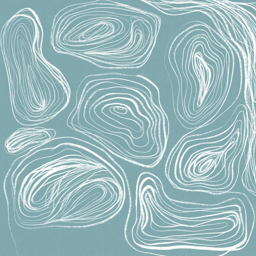


Thumbnail 3: File ID = 827


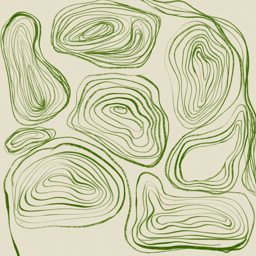

 33%|███▎      | 1/3 [01:02<02:04, 62.38s/it]



Query: 'portrait of a person'

Top 10 matching tags:
 tag_id  tag_name  similarity                       file_ids
   1145 visualart    0.374485                [712, 631, 620]
   1323  portrait    0.486856 [4027, 4818, 5171, 7377, 8926]
   1440   pinkart    0.377014                    [586, 9428]

Found 10 unique files matching query tags:
['4027', '4818', '5171', '586', '620', '631'] ...

Displaying top 3 thumbnails:
Thumbnail 1: File ID = 4027


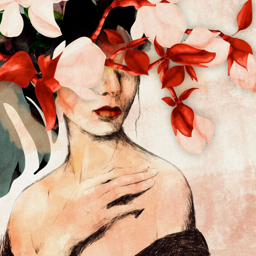


Thumbnail 2: File ID = 4818


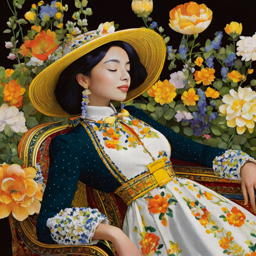


Thumbnail 3: File ID = 5171


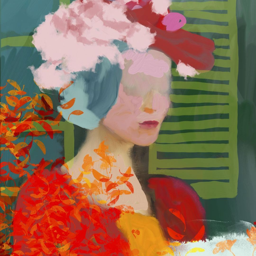

 67%|██████▋   | 2/3 [02:03<01:01, 61.37s/it]



Query: 'abstract art with bright colors'

Top 10 matching tags:
 tag_id         tag_name  similarity                                                                          file_ids
   1103      abstractart    0.538726 [827, 712, 818, 5193, 5359, 571, 574, 586, 631, 599, 620, 1243, 9428, 9731, 8695]
   1422 abstractpainting    0.543857                                                                            [5359]
   1423      colorfulart    0.547450                                                           [5359, 586, 1243, 9428]

Found 15 unique files matching query tags:
['1243', '5193', '5359', '571', '574', '586'] ...

Displaying top 3 thumbnails:
Thumbnail 1: File ID = 1243


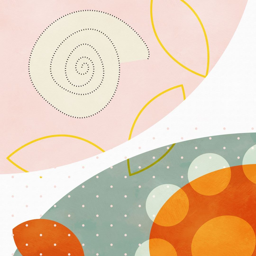


Thumbnail 2: File ID = 5193


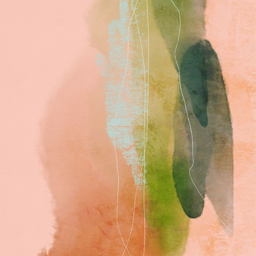


Thumbnail 3: File ID = 5359


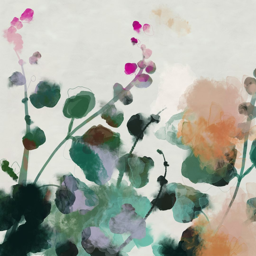

100%|██████████| 3/3 [03:03<00:00, 61.16s/it]

In [22]:
import torch
from tqdm import tqdm
from IPython.display import display, Image

print("Loading model...")
model = SentenceTransformer("Qwen/Qwen3-Embedding-0.6B")
print("Model loaded!")

print("Loading tags from database...")
df_systag, df_tagmap = get_tags()
print(f"Loaded {len(df_systag)} tags and {len(df_tagmap)} mappings")

# Test queries
test_queries = [
    "A painting with green landscape scene",
    "portrait of a person",
    "abstract art with bright colors",
]

def display_top_thumbnails(file_ids, top_n=3):
    """
    Display thumbnails for the top N file IDs from the search results.
    
    Args:
        file_ids: List of file IDs to display
        top_n: Number of thumbnails to display (default 3)
    """
    if not file_ids:
        print("No files to display.")
        return
    
    print(f"\nDisplaying top {min(top_n, len(file_ids))} thumbnails:")
    for i, file_id in enumerate(file_ids[:top_n]):
        print(f"Thumbnail {i+1}: File ID = {file_id}")
        file_path = "/images/"
        try:
            img = get_images(file_id, file_path)
        except Exception as e:
            print(f"  Failed to load image: {e}")
        print()

for query in tqdm(test_queries):
    print(f"\n{'='*60}")
    print(f"Query: '{query}'")
    print(f"{'='*60}")
    
    # Get top matching tags with file IDs
    top_tags = search_tags_with_nlp(query, top_k=3)
    print("\nTop 10 matching tags:")
    print(top_tags.to_string(index=False))
    
    # Get all combined file IDs
    file_ids, _ = get_all_file_ids_from_query(query, top_k=3)
    print(f"\nFound {len(file_ids)} unique files matching query tags:")
    print(file_ids[:6], "..." if len(file_ids) > 6 else "")
    
    # Display top 3 thumbnails
    display_top_thumbnails(file_ids, top_n=3)